In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Twitter_Data.csv", header=None)
df.head()

,0,1
0,clean_text,category
1,when modi promised “minimum government maximum...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1


In [4]:
print(df.shape)
df.head(10)

(162981, 2)


,0,1
0,clean_text,category
1,when modi promised “minimum government maximum...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1
5,answer who among these the most powerful world...,1
6,kiya tho refresh maarkefir comment karo,0
7,surat women perform yagna seeks divine grace f...,0
8,this comes from cabinet which has scholars lik...,0
9,with upcoming election india saga going import...,1


In [6]:
print(df.columns)
df.head()

Index([0, 1], dtype='int64')


,0,1
0,clean_text,category
1,when modi promised “minimum government maximum...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1


In [7]:
df.columns = ['clean_text', 'category']
df = df.iloc[1:]
df.head()

,clean_text,category
1,when modi promised “minimum government maximum...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1
5,answer who among these the most powerful world...,1


In [9]:
df.columns = ['clean_text', 'category']
df = df.iloc[1:]
df['category'] = pd.to_numeric(df['category'])

print(df.head())
print(df.columns)

                                          clean_text  category
2  talk all the nonsense and continue all the dra...       0.0
3  what did just say vote for modi  welcome bjp t...       1.0
4  asking his supporters prefix chowkidar their n...       1.0
5  answer who among these the most powerful world...       1.0
6           kiya tho refresh maarkefir comment karo        0.0
Index(['clean_text', 'category'], dtype='object')


In [10]:
X = df['clean_text']
y = df['category']

In [12]:
print(df['clean_text'].isnull().sum())
print(df['category'].isnull().sum())
print(df.shape)

4
7
(162979, 2)


In [13]:
df = df.dropna(subset=['clean_text', 'category'])
df['clean_text'] = df['clean_text'].astype(str)
df['clean_text'] = df['clean_text'].str.strip()
df = df[df['clean_text'] != ""]

print(df.shape)
print(df.head())

(162967, 2)
                                          clean_text  category
2  talk all the nonsense and continue all the dra...       0.0
3  what did just say vote for modi  welcome bjp t...       1.0
4  asking his supporters prefix chowkidar their n...       1.0
5  answer who among these the most powerful world...       1.0
6            kiya tho refresh maarkefir comment karo       0.0


In [14]:
X = df['clean_text']
y = df['category']

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8553414738909002


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.87      0.74      0.80      7111
         0.0       0.80      0.96      0.87     11028
         1.0       0.91      0.83      0.87     14455

    accuracy                           0.86     32594
   macro avg       0.86      0.84      0.85     32594
weighted avg       0.86      0.86      0.85     32594



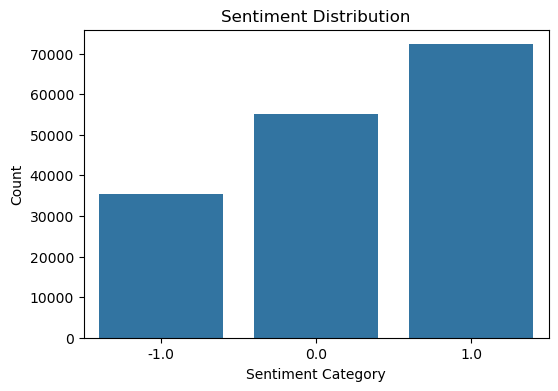

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='category', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.show()

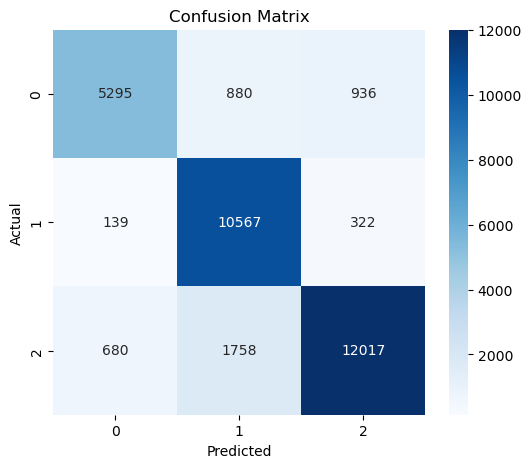

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
sample = [
    "This government is doing amazing work",
    "This is the worst policy ever",
    "The news today was normal"
]

sample_vec = vectorizer.transform(sample)

predictions = model.predict(sample_vec)

for text, pred in zip(sample, predictions):
    print(text, "→ Sentiment:", pred)

This government is doing amazing work → Sentiment: 1.0
This is the worst policy ever → Sentiment: -1.0
The news today was normal → Sentiment: 1.0
